# Algorithm Comparison Notebook

Load `.pkl` files produced by the experiment scripts and visualize:
- Convergence curves
- Robustness (mean ± std over 30 runs)
- Scalability (fitness vs dimension)
- Diversity (exploration behaviour)
- Execution time

**Run order:**
```bash
python experiments/convergence_experiment.py           # → results/convergence_*.pkl
python experiments/robustness_experiment.py            # → results/robustness_rosenbrock.pkl
```

In [8]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import seaborn as sns
import pandas as pd
from pathlib import Path
src_path = Path.cwd().parent
sys.path.insert(0, str(src_path))
print("Added to path:", src_path)  # adjust if notebook is in a sub-folder

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

from utils.visualize import (
    load_pkl,
    load_summary_csv,
    plot_convergence,
    plot_convergence_runs,
    plot_robustness_boxplot,
    plot_robustness_bar,
    plot_scalability,
    plot_time_comparison,
    plot_diversity,
    plot_dashboard,
)

mpl.rcParams.update({
    'figure.dpi'     : 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
plt.style.use('seaborn-v0_8-whitegrid')
print('Imports OK')

Added to path: D:\CODE\AI\AI1_search-algorithms\src
Imports OK


## 1. Load Data

In [12]:
sphere_data      = load_pkl('../results/convergence_sphere.pkl')
rastrigin_data   = load_pkl('../results/convergence_rastrigin.pkl')
rosenbrock_data  = load_pkl('../results/convergence_rosenbrock.pkl')

# Robustness (Rosenbrock)
rob_data         = load_pkl('../results/robustness_rosenbrock.pkl')
rob_raw          = rob_data['raw']      # list[dict] — individual run results
rob_summary_df   = load_summary_csv('../results/robustness_rosenbrock.csv')

print('Sphere algos    :', list(sphere_data.keys()))
print('Rastrigin algos :', list(rastrigin_data.keys()))
print('Rosenbrock algos:', list(rosenbrock_data.keys()))
print('Robustness runs :', len(rob_raw))

Sphere algos    : ['HC', 'GA', 'PSO', 'DE', 'SA', 'TLBO', 'GSA']
Rastrigin algos : ['HC', 'GA', 'DE', 'SA', 'CS', 'CA', 'ABC', 'FA']
Rosenbrock algos: ['GA', 'HC', 'PSO', 'DE', 'SA', 'TLBO', 'ABC', 'SFO']
Robustness runs : 720


In [21]:
# Helper: flatten convergence PKL into the format expected by plot_convergence
# plot_convergence accepts:  { algo_name: {"convergence_curve": ..., "dimensions": int} }
# Our PKL structure is:      { algo_name: { dim_int: full_result_dict } }

def flatten_for_dim(pkl_data, dim):
    """Return {algo: result_dict} for a fixed dimension."""
    return {
        algo: dim_data[dim]
        for algo, dim_data in pkl_data.items()
        if dim in dim_data
    }

# Available dimensions depend on config.json — adjust as needed
DIM = 30
print(f'Using dim = {DIM}')

Using dim = 30


---
## 2. Sphere Function — Convergence

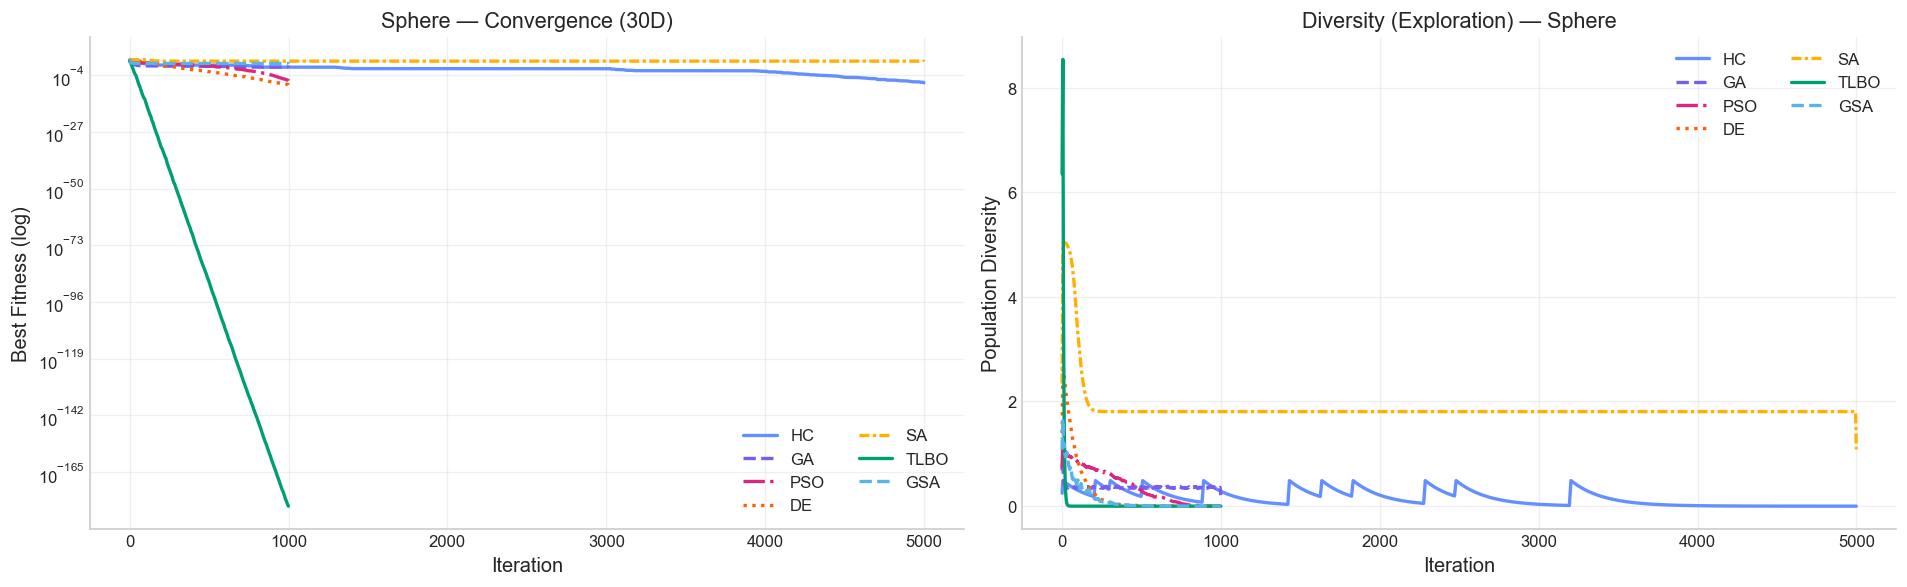

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sphere_dim = flatten_for_dim(sphere_data, DIM)

plot_convergence(
    sphere_dim,
    problem='Sphere',
    log_scale=True,
    smooth_window=5,
    title=f'Sphere — Convergence ({DIM}D)',
    ax=axes[0],
)

plot_diversity(
    sphere_dim,
    problem='Sphere',
    smooth_window=10,
    ax=axes[1],
)

plt.tight_layout()
plt.show()

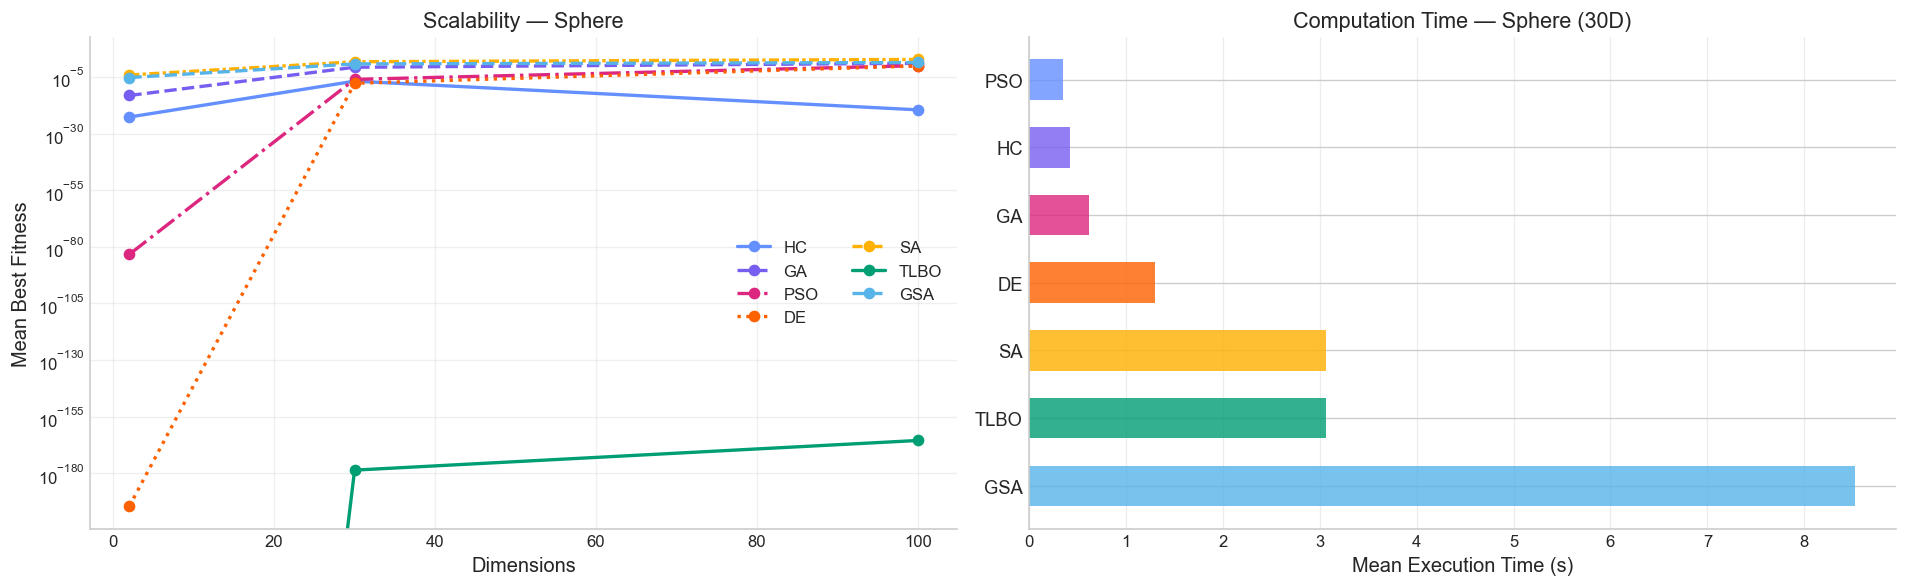

In [24]:
# Scalability: compare performance across all available dimensions
import pandas as pd

rows = []
for algo, dim_data in sphere_data.items():
    for dim, res in dim_data.items():
        rows.append({'algorithm': algo, 'dimensions': dim,
                     'mean_fitness': res['best_fitness'],
                     'mean_time': res['execution_time_seconds']})
sphere_summary = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_scalability(sphere_summary, problem='Sphere', ax=axes[0])
plot_time_comparison(sphere_summary, dim=DIM, problem='Sphere', ax=axes[1])
plt.tight_layout()
plt.show()

---
## 3. Rastrigin Function — Exploration vs Exploitation

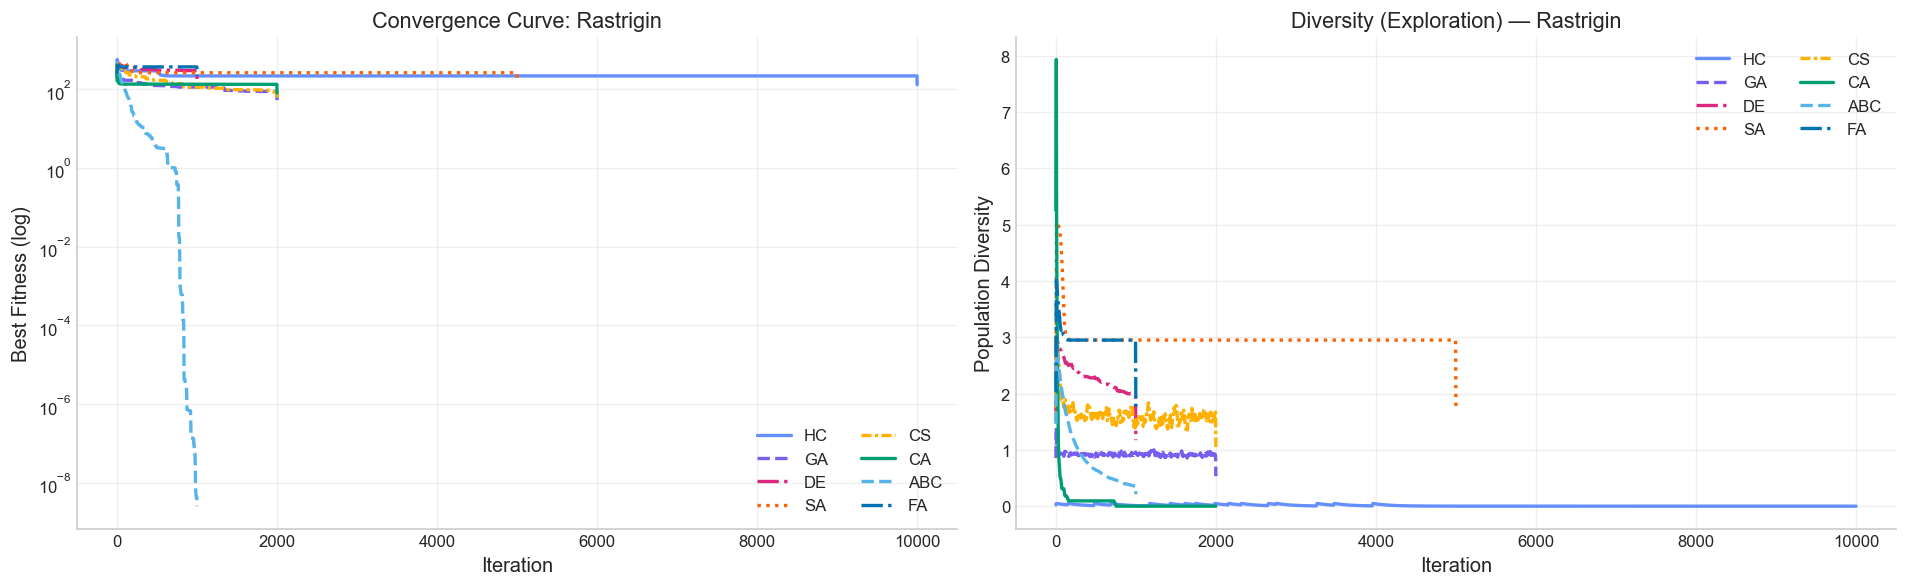

In [25]:
rastrigin_dim = flatten_for_dim(rastrigin_data, DIM)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

plot_convergence(
    rastrigin_dim,
    problem='Rastrigin',
    log_scale=True,
    smooth_window=5,
    ax=axes[0],
)

# HC is expected to fail — highlight it visually by plotting it last
plot_diversity(
    rastrigin_dim,
    problem='Rastrigin',
    smooth_window=10,
    ax=axes[1],
)

plt.tight_layout()
plt.show()

---
## 4. Rosenbrock Function — Convergence

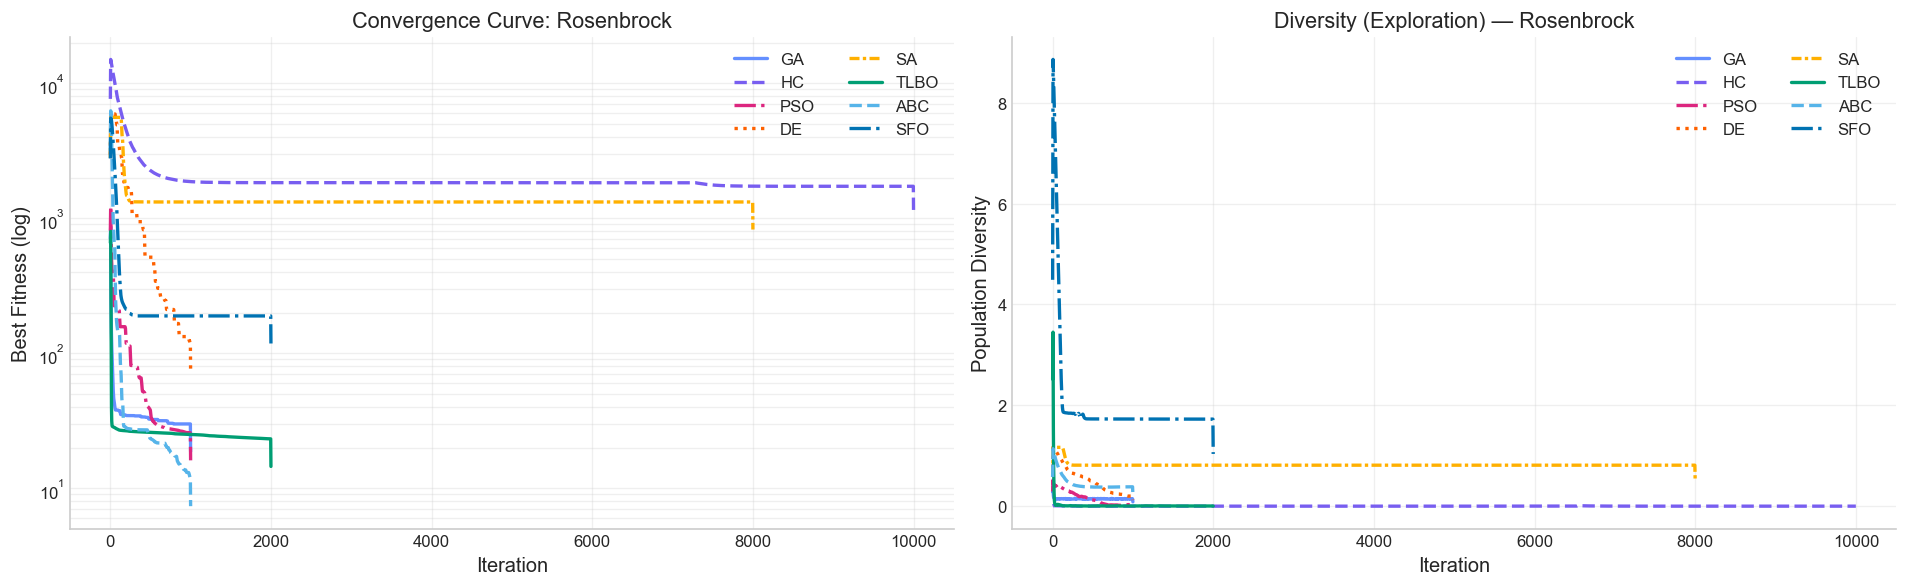

In [30]:
rosenbrock_dim = flatten_for_dim(rosenbrock_data, DIM)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

plot_convergence(
    rosenbrock_dim,
    problem='Rosenbrock',
    log_scale=True,
    smooth_window=8,
    ax=axes[0],
)

plot_diversity(
    rosenbrock_dim,
    problem='Rosenbrock',
    smooth_window=10,
    ax=axes[1],
)

plt.tight_layout()
plt.show()

---
## 5. Rosenbrock — Robustness (30 runs)

In [31]:
rob_summary_df

,algorithm,problem,dimensions,n_runs,mean_fitness,std_fitness,min_fitness,max_fitness,median_fitness,mean_time
0,ABC,rosenbrock,2,30,1.026902e-03,1.304209e-03,2.247446e-05,5.262212e-03,5.280475e-04,10.572481
1,ABC,rosenbrock,30,30,1.264837e+01,5.753593e+00,1.147337e+00,2.366599e+01,1.283927e+01,10.418819
2,ABC,rosenbrock,100,30,2.602438e+02,5.147564e+01,9.664694e+01,3.341579e+02,2.722852e+02,10.618347
3,DE,rosenbrock,2,30,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.083289
4,DE,rosenbrock,30,30,1.074243e+02,3.841685e+01,6.442058e+01,2.300250e+02,9.622344e+01,2.223378
5,DE,rosenbrock,100,30,2.682809e+03,5.245545e+02,1.611540e+03,3.816889e+03,2.674184e+03,2.304146
6,GA,rosenbrock,2,30,4.143268e-03,9.609038e-03,2.757589e-07,4.428449e-02,5.081676e-04,0.258597
7,GA,rosenbrock,30,30,3.115234e+01,6.685080e-01,2.960747e+01,3.275165e+01,3.100128e+01,0.655627
8,GA,rosenbrock,100,30,2.767657e+02,1.468700e+01,2.498375e+02,3.127617e+02,2.750406e+02,1.118077
9,HC,rosenbrock,2,30,3.588386e-02,1.057573e-01,1.539520e-13,5.725369e-01,4.332668e-07,0.524768


D:\CODE\AI\AI1_search-algorithms\src\notebooks\..\utils\visualize.py:49: UserWarning: Glyph 9670 (\N{BLACK DIAMOND}) missing from font(s) Arial.
  fig.tight_layout()
D:\CODE\AI\AI1_search-algorithms\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9670 (\N{BLACK DIAMOND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


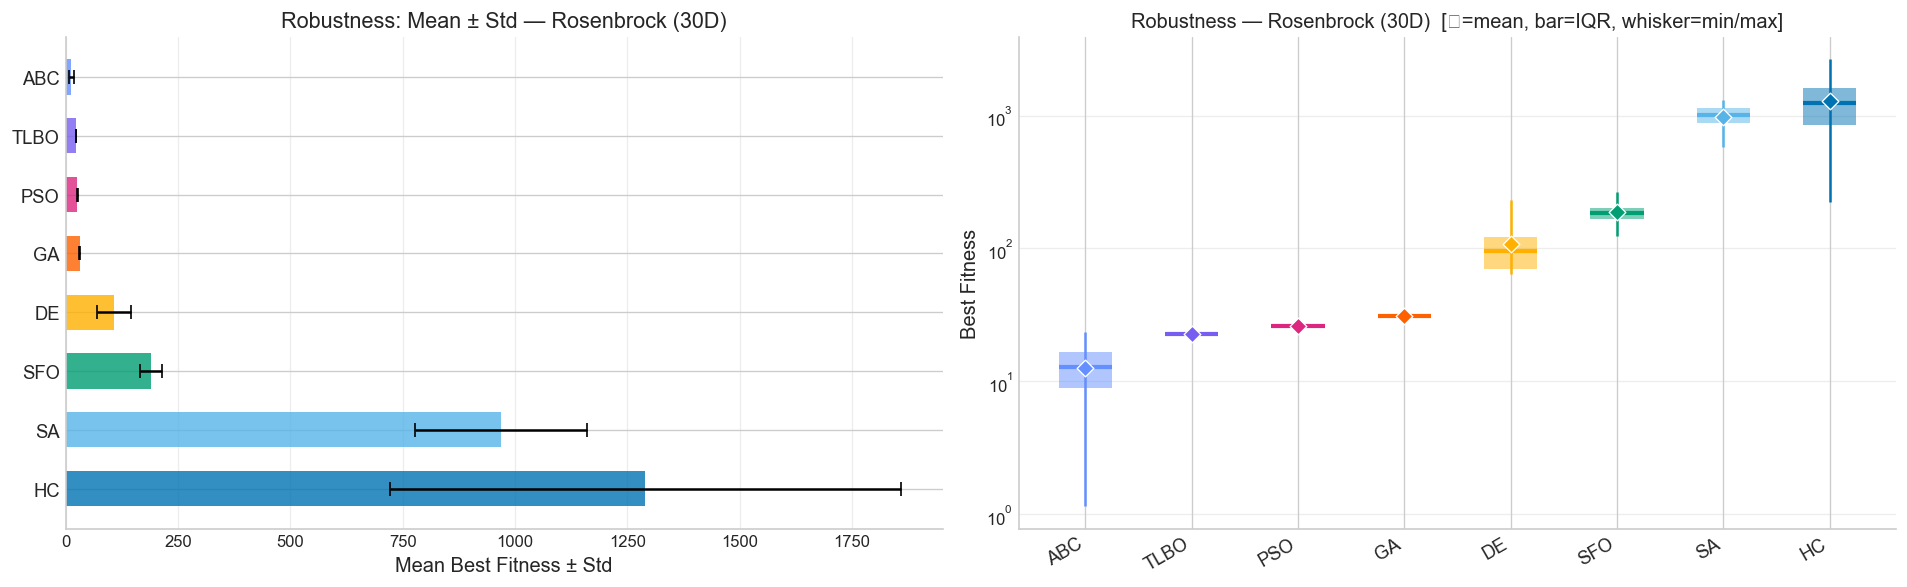

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

plot_robustness_bar(
    rob_summary_df,
    dim=DIM,
    problem='Rosenbrock',
    ax=axes[0],
)

plot_robustness_boxplot(
    rob_summary_df,
    dim=DIM,
    problem='Rosenbrock',
    ax=axes[1],
)

plt.tight_layout()
plt.show()

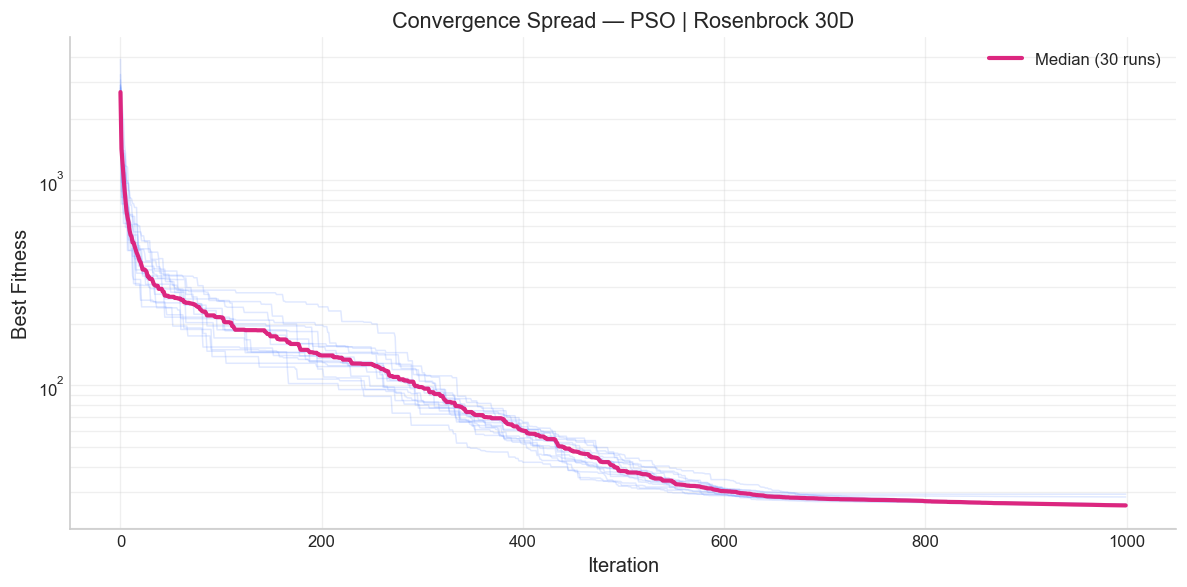

In [33]:
# Spaghetti plot — all 30 convergence curves for one algorithm
# Change ALGO to inspect a different one

ALGO = 'PSO'

algo_runs = [r for r in rob_raw if r['algorithm'] == ALGO]

fig, ax = plt.subplots(figsize=(10, 5))
plot_convergence_runs(
    algo_runs,
    algorithm=ALGO,
    dim=DIM,
    problem='Rosenbrock',
    ax=ax,
)
plt.show()

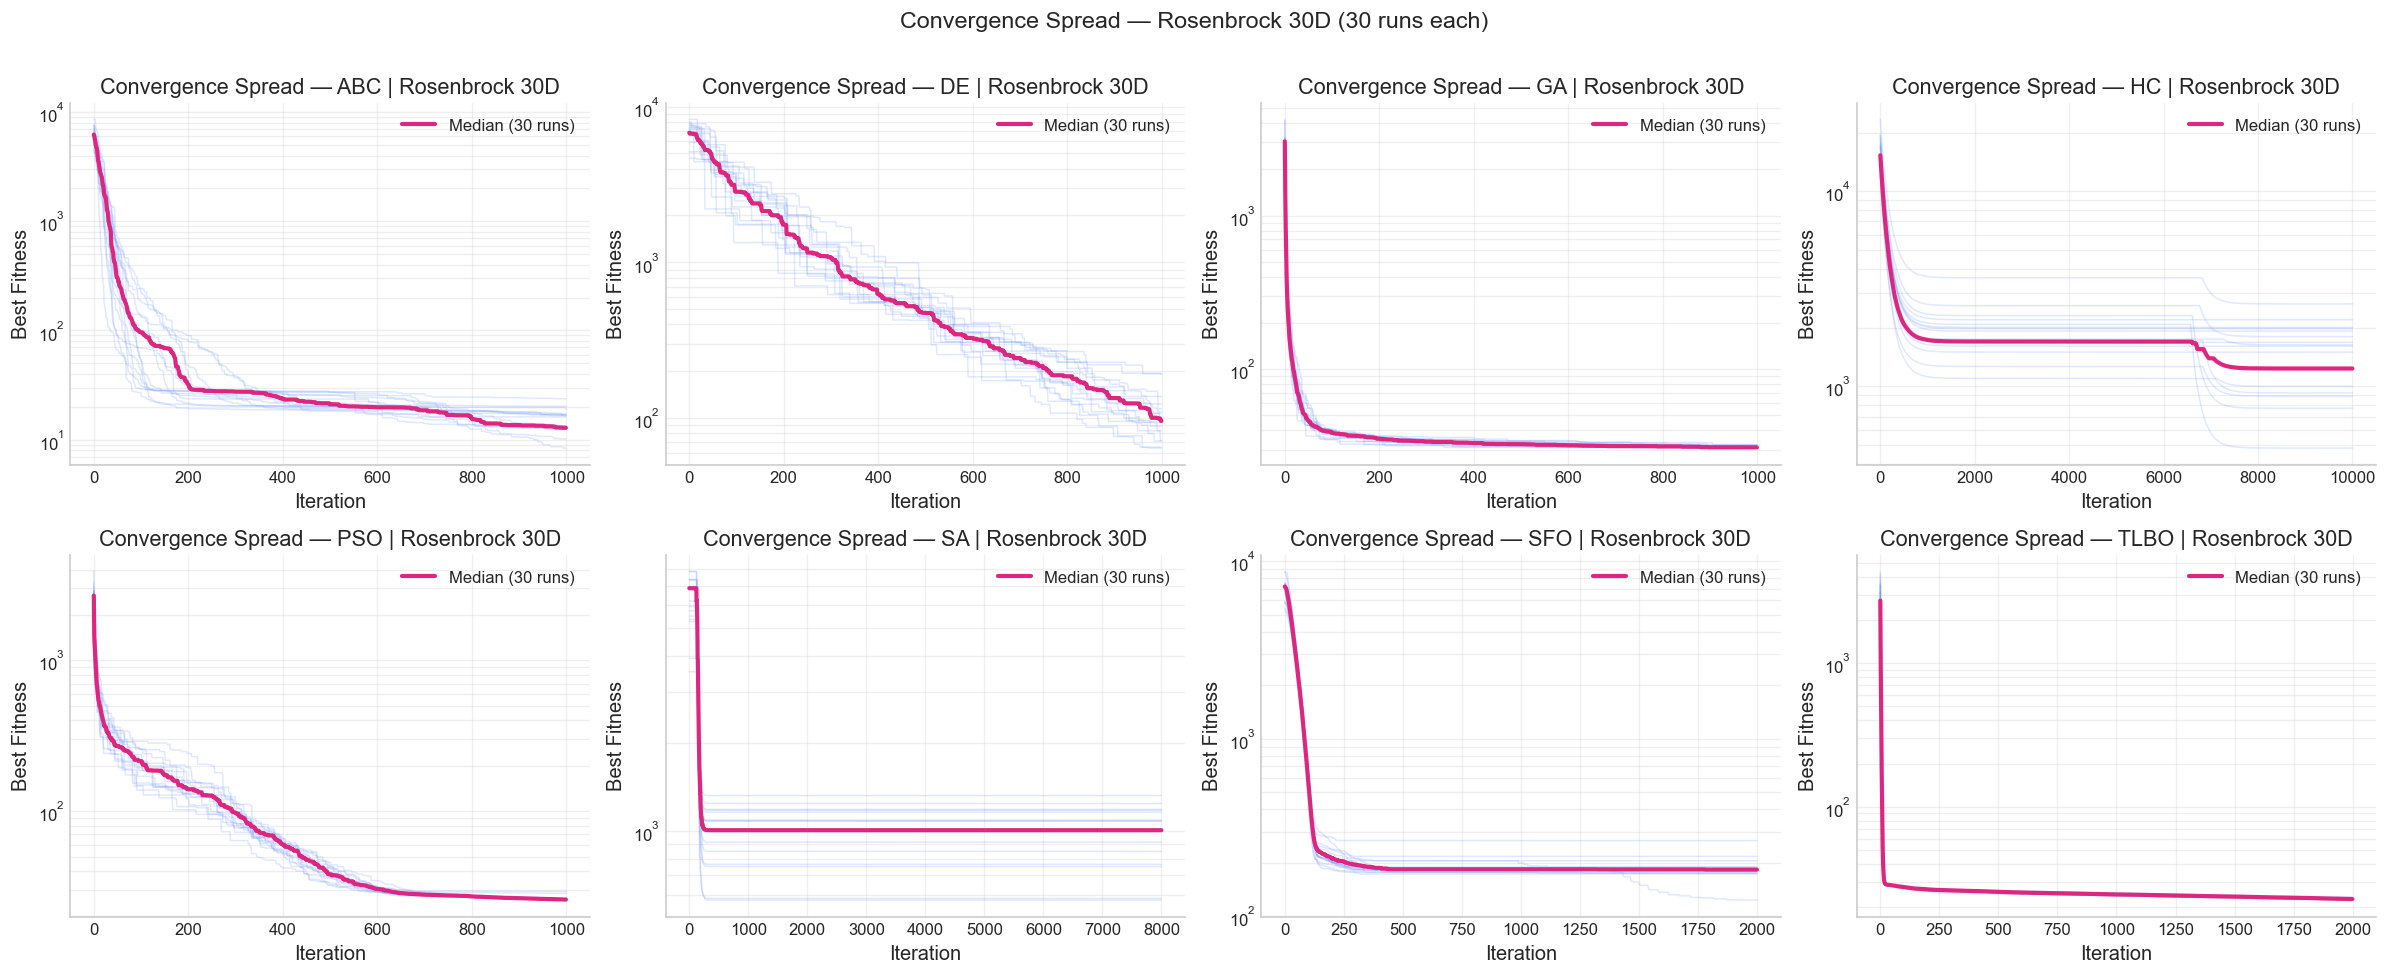

In [34]:
# Compare spaghetti for ALL Rosenbrock algorithms at once

algos_ros = sorted(set(r['algorithm'] for r in rob_raw))
n         = len(algos_ros)
ncols     = 4
nrows     = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 4))
axes_flat = axes.flatten()

for i, algo in enumerate(algos_ros):
    algo_runs = [r for r in rob_raw if r['algorithm'] == algo]
    plot_convergence_runs(
        algo_runs,
        algorithm=algo,
        dim=DIM,
        problem='Rosenbrock',
        ax=axes_flat[i],
    )

# Hide unused axes
for j in range(i + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.suptitle(f'Convergence Spread — Rosenbrock {DIM}D (30 runs each)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---
## 6. Full Dashboards

Saved → ../results/dashboard_rosenbrock.png


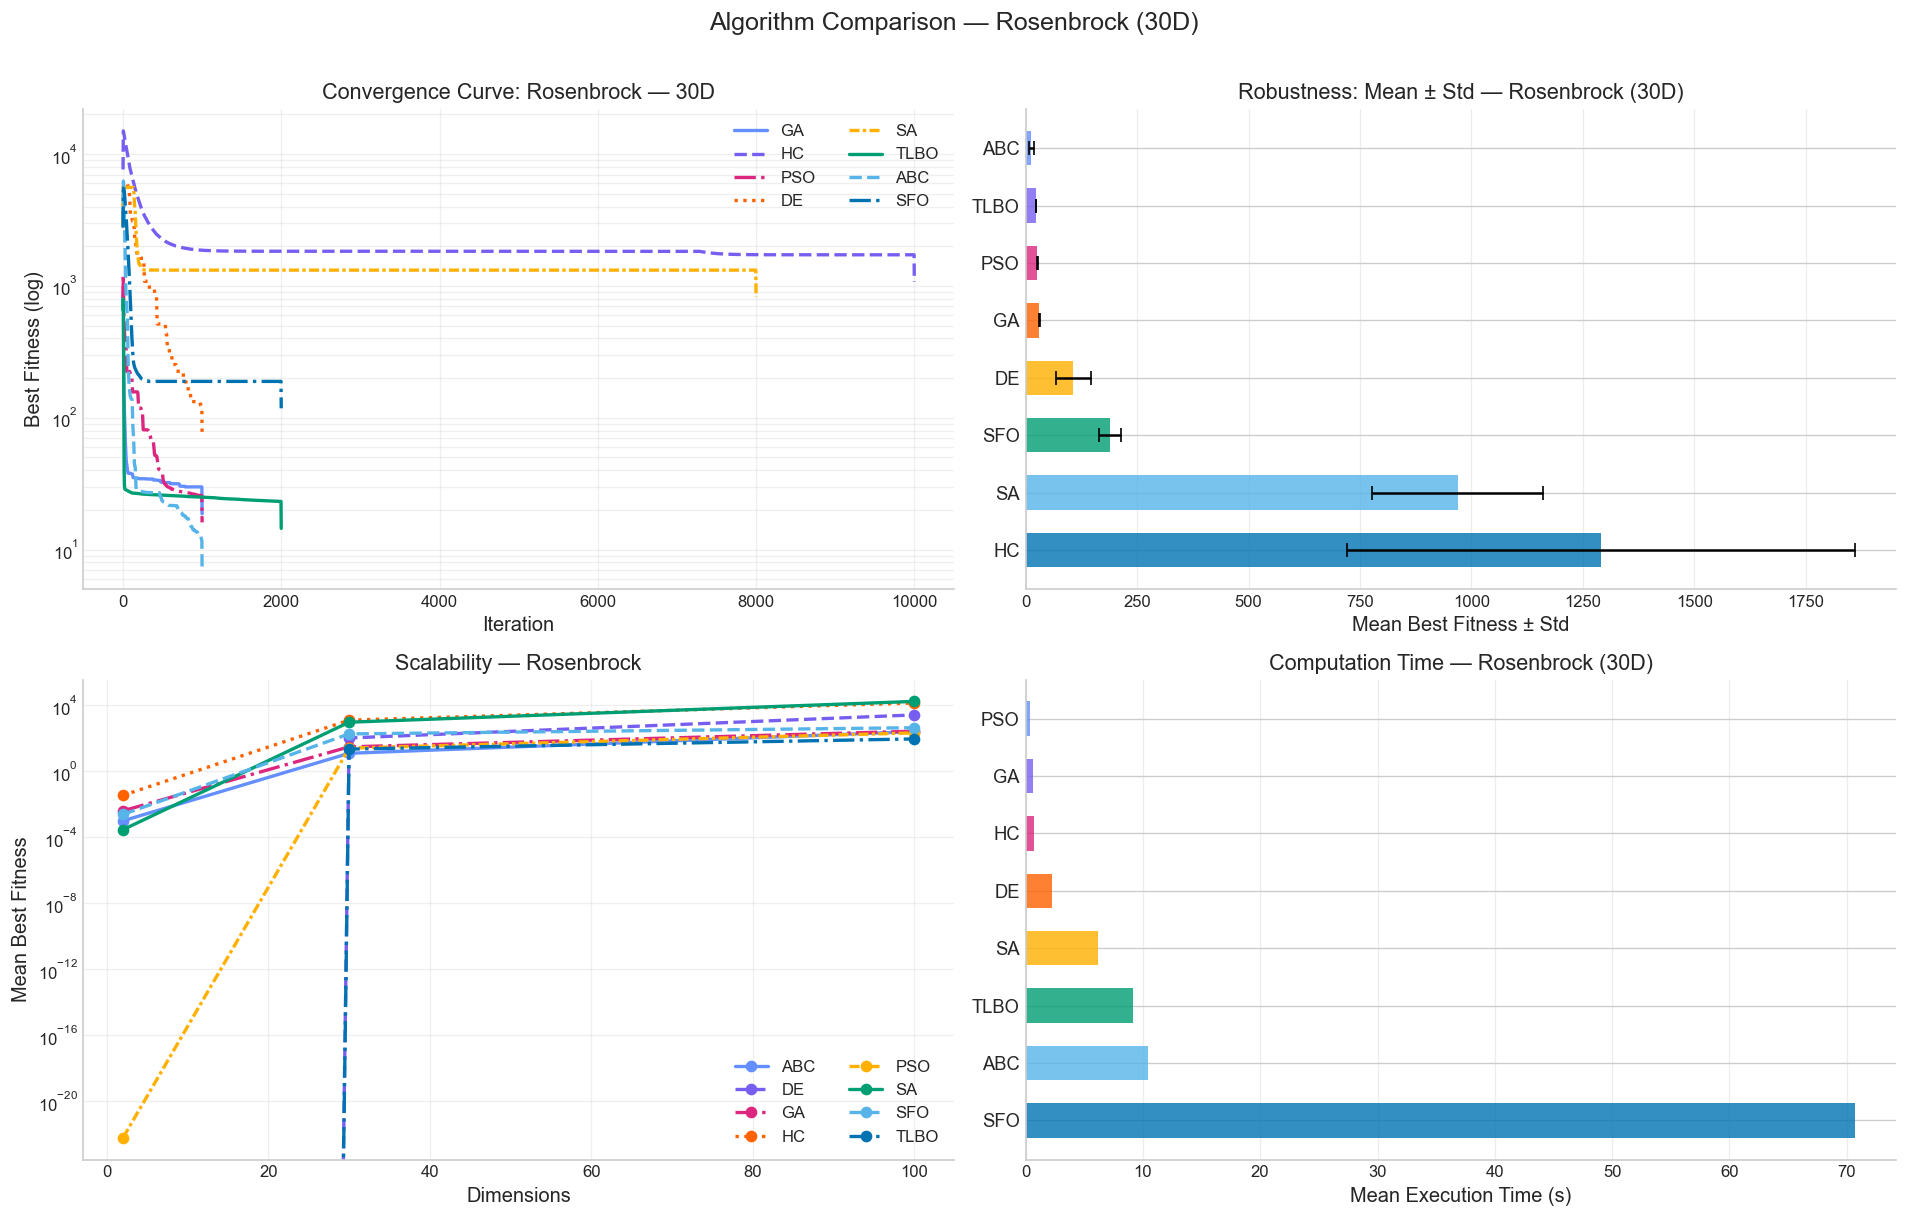

In [40]:
# Build a combined summary df for Rosenbrock (convergence PKL → summary)
rows_r = []
for algo, dim_data in rosenbrock_data.items():
    for dim, res in dim_data.items():
        rows_r.append({
            'algorithm'    : algo,
            'dimensions'   : dim,
            'mean_fitness' : res['best_fitness'],
            'std_fitness'  : 0.0,      # single run
            'min_fitness'  : res['best_fitness'],
            'max_fitness'  : res['best_fitness'],
            'median_fitness': res['best_fitness'],
            'mean_time'    : res['execution_time_seconds'],
        })
rosenbrock_summary_single = pd.DataFrame(rows_r)

# Use robustness summary where available (it has real std)
rosenbrock_dash_summary = rob_summary_df  # or rosenbrock_summary_single

plot_dashboard(
    rosenbrock_dim,
    rosenbrock_dash_summary,
    dim=DIM,
    problem='Rosenbrock',
    smooth_window=8,
    save_path='../results/dashboard_rosenbrock.png',
)
plt.show()

KeyError: 'std_fitness'

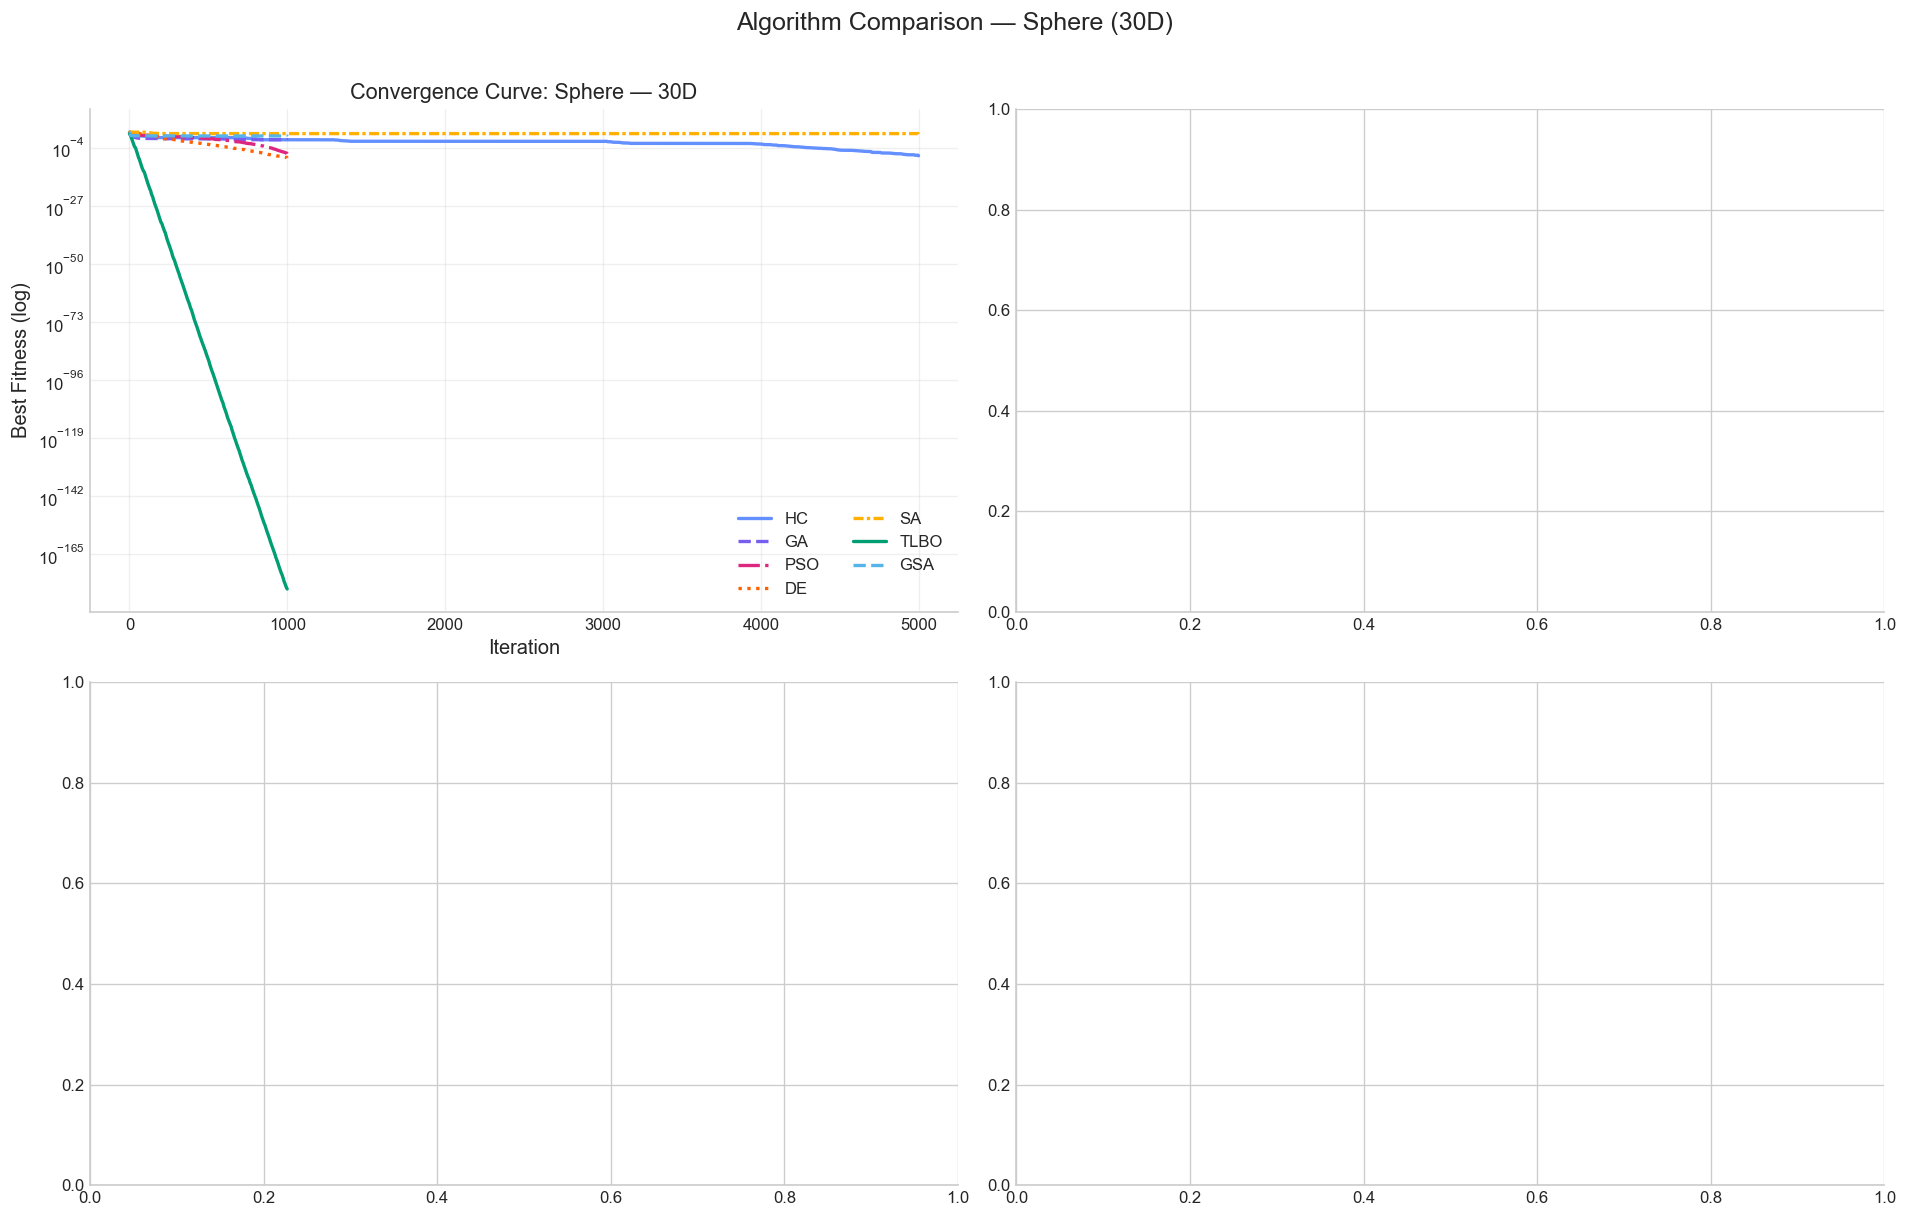

In [41]:
# Sphere dashboard (single run summary)
plot_dashboard(
    flatten_for_dim(sphere_data, DIM),
    sphere_summary,
    dim=DIM,
    problem='Sphere',
    smooth_window=5,
    save_path='results/dashboard_sphere.png',
)
plt.show()

In [ ]:
# Rastrigin dashboard
rows_ra = []
for algo, dim_data in rastrigin_data.items():
    for dim, res in dim_data.items():
        rows_ra.append({'algorithm': algo, 'dimensions': dim,
                        'mean_fitness': res['best_fitness'], 'std_fitness': 0.0,
                        'min_fitness': res['best_fitness'], 'max_fitness': res['best_fitness'],
                        'median_fitness': res['best_fitness'],
                        'mean_time': res['execution_time_seconds']})
rastrigin_summary = pd.DataFrame(rows_ra)

plot_dashboard(
    flatten_for_dim(rastrigin_data, DIM),
    rastrigin_summary,
    dim=DIM,
    problem='Rastrigin',
    smooth_window=5,
    save_path='results/dashboard_rastrigin.png',
)
plt.show()